In [ ]:
# faz a conexão com o google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
cd /content/gdrive/My Drive/


/content/gdrive/My Drive


In [ ]:
#importa as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd

# Caminho do arquivo
caminho = '/content/gdrive/My Drive/Colab Notebooks/Trabalho/Dados.xml'

# Parse do XML
tree = ET.parse(caminho)
root = tree.getroot()

# Lista de dados
dados = []

# Procurar os registros principais (ajuste a tag se for diferente)
for chamado in root.findall('.//chamado'):
    registro = {}
    for campo in chamado:
        registro[campo.tag] = campo.text.strip() if campo.text else ''
    dados.append(registro)

# Criar um NOVO DataFrame
df = pd.DataFrame(dados)

# Agora sim você pode ver as colunas
print("Colunas disponíveis:", df.columns.tolist())
print(df.head())


Colunas disponíveis: ['codticket', 'protocolo', 'codproduto', 'codtipoassunto', 'titulo', 'mensagem', 'datahora', 'idcliente', 'prioridade', 'codatendente', 'acompanhaemailatendente', 'acompanhaemailcliente', 'tag', 'tipocliente', 'codcliente', 'codstatus', 'mimetype', 'mensagens', 'comentarios', 'anexos', 'campos-extras']
  codticket protocolo codproduto codtipoassunto  \
0  10396026         1      81375         137908   
1  21128212         2      81375         137908   
2  21128316         3      81375         137908   
3  21128769         4      81375         199479   
4  21156277         5      81375         199479   

                                 titulo  \
0         <![CDATA[\nTESTE CHAMADO\n]]>   
1   <![CDATA[\nImpressora com erro\n]]>   
2     <![CDATA[\nAtualizar Windows\n]]>   
3                 <![CDATA[\nTeste\n]]>   
4  <![CDATA[\nteste Chamado Victor\n]]>   

                                            mensagem                datahora  \
0   <![CDATA[\n&lt;p&gt;TESTE

In [ ]:
print('tipocliente' in df.columns)


True


In [ ]:
print(df.columns.tolist())


['codticket', 'protocolo', 'codproduto', 'codtipoassunto', 'titulo', 'mensagem', 'datahora', 'idcliente', 'prioridade', 'codatendente', 'acompanhaemailatendente', 'acompanhaemailcliente', 'tag', 'tipocliente', 'codcliente', 'codstatus', 'mimetype', 'mensagens', 'comentarios', 'anexos', 'campos-extras']


In [ ]:
import pandas as pd

# Lista onde serão armazenados os dados
dados = []

# Procurar todos os <chamado> no XML
for chamado in root.findall('.//chamado'):  # ajuste a tag se for diferente
    registro = {}
    for campo in chamado:
        registro[campo.tag] = campo.text.strip() if campo.text else ''
    dados.append(registro)

# Criar DataFrame
df = pd.DataFrame(dados)

# Visualizar os dados
print(df.head())


  codticket protocolo codproduto codtipoassunto  \
0  10396026         1      81375         137908   
1  21128212         2      81375         137908   
2  21128316         3      81375         137908   
3  21128769         4      81375         199479   
4  21156277         5      81375         199479   

                                 titulo  \
0         <![CDATA[\nTESTE CHAMADO\n]]>   
1   <![CDATA[\nImpressora com erro\n]]>   
2     <![CDATA[\nAtualizar Windows\n]]>   
3                 <![CDATA[\nTeste\n]]>   
4  <![CDATA[\nteste Chamado Victor\n]]>   

                                            mensagem                datahora  \
0   <![CDATA[\n&lt;p&gt;TESTE CHAMADO&lt;/p&gt;\n]]>  2020-01-29 18:28:58-03   
1  <![CDATA[\n\n\n&lt;p&gt;Impressora com erro no...  2021-10-27 16:14:26-03   
2  <![CDATA[\n\n\n&lt;p&gt;Teste atualizar&amp;nb...  2021-10-27 16:16:56-03   
3  <![CDATA[\n\n\n&lt;p&gt;teste 22&lt;/p&gt;\n\n...  2021-10-27 16:27:28-03   
4  <![CDATA[\n\n\n&lt;p&gt;Teste F

In [ ]:
print(type(df))



<class 'pandas.core.frame.DataFrame'>


ano
2020       1
2021     236
2022    1801
2023    1952
2024    1940
2025     378
Name: count, dtype: int64


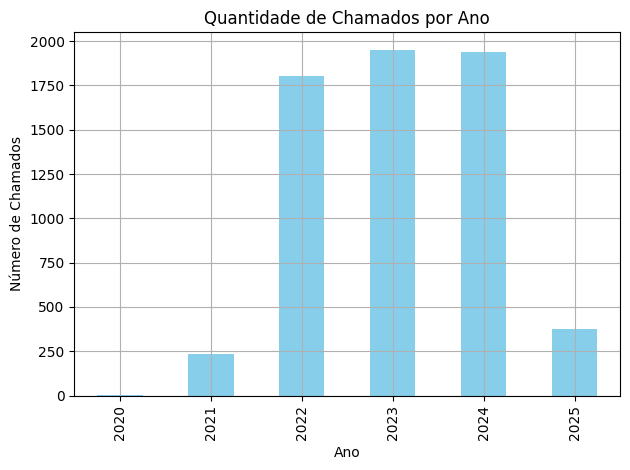

In [ ]:
df['datahora'] = pd.to_datetime(df['datahora'], errors='coerce')


df['ano'] = df['datahora'].dt.year

# Conta quantos chamados por ano
chamados_por_ano = df['ano'].value_counts().sort_index()

# Exibe os dados
print(chamados_por_ano)


chamados_por_ano.plot(kind='bar', color='skyblue')
plt.title('Quantidade de Chamados por Ano')
plt.xlabel('Ano')
plt.ylabel('Número de Chamados')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.show()


In [ ]:
import pandas as pd

# Converte a coluna 'datahora' para datetime
df['datahora'] = pd.to_datetime(df['datahora'], errors='coerce')

# Cria uma nova coluna com o ano
df['ano'] = df['datahora'].dt.year

# Visualiza os dados
print(df[['codticket', 'datahora', 'ano']].head())


  codticket                  datahora   ano
0  10396026 2020-01-29 18:28:58-03:00  2020
1  21128212 2021-10-27 16:14:26-03:00  2021
2  21128316 2021-10-27 16:16:56-03:00  2021
3  21128769 2021-10-27 16:27:28-03:00  2021
4  21156277 2021-10-28 16:48:20-03:00  2021


Index(['codticket', 'protocolo', 'codproduto', 'codtipoassunto', 'titulo',
       'mensagem', 'datahora', 'idcliente', 'prioridade', 'codatendente',
       'acompanhaemailatendente', 'acompanhaemailcliente', 'tag',
       'tipocliente', 'codcliente', 'codstatus', 'mimetype', 'mensagens',
       'comentarios', 'anexos', 'campos-extras', 'ano'],
      dtype='object')
tipocliente
E    6308
Name: count, dtype: int64


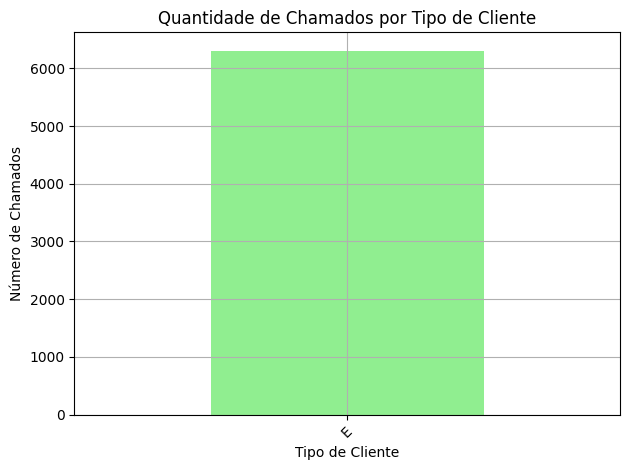

In [ ]:
print(df.columns)


chamados_por_tipo = df['tipocliente'].value_counts()

print(chamados_por_tipo)

chamados_por_tipo.plot(kind='bar', color='lightgreen')
plt.title('Quantidade de Chamados por Tipo de Cliente')
plt.xlabel('Tipo de Cliente')
plt.ylabel('Número de Chamados')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Index(['codticket', 'protocolo', 'codproduto', 'codtipoassunto', 'titulo',
       'mensagem', 'datahora', 'idcliente', 'prioridade', 'codatendente',
       'acompanhaemailatendente', 'acompanhaemailcliente', 'tag',
       'tipocliente', 'codcliente', 'codstatus', 'mimetype', 'mensagens',
       'comentarios', 'anexos', 'campos-extras', 'ano'],
      dtype='object')
codatendente
71301     2124
115130    1760
106960    1558
102344     547
102345     188
129305     107
147395      12
            12
Name: count, dtype: int64


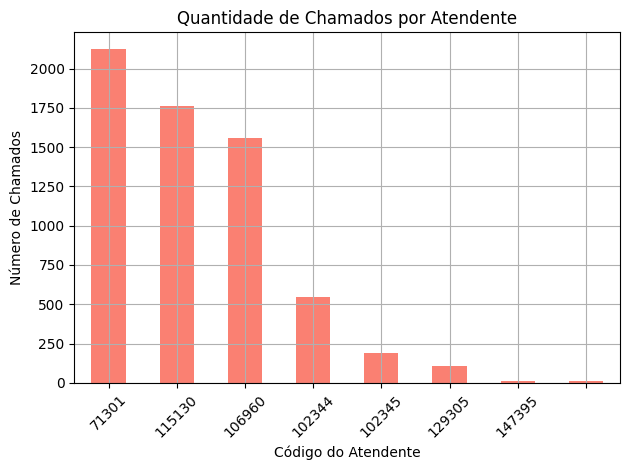

In [ ]:
print(df.columns)

chamados_por_atendente = df['codatendente'].value_counts().sort_values(ascending=False)


print(chamados_por_atendente)

chamados_por_atendente.plot(kind='bar', color='salmon')
plt.title('Quantidade de Chamados por Atendente')
plt.xlabel('Código do Atendente')
plt.ylabel('Número de Chamados')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


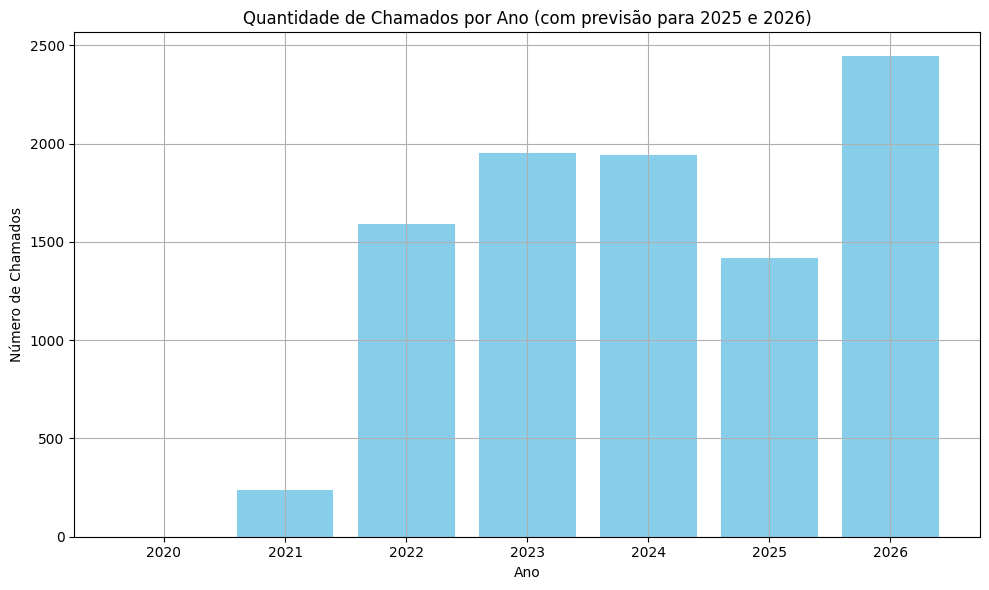

Estimativa total para 2025: 1416 chamados
Previsão para 2026: 2444 chamados


In [ ]:

# Possivel previsão de chamados para 2026/2025
dados = {
    2020: 1,
    2021: 236,
    2022: 1592,
    2023: 1952,
    2024: 1940,
    2025: 236  # Dados até fevereiro
}

# De acordo com a media mensal
meses_disponiveis = 2
media_mensal_2025 = dados[2025] / meses_disponiveis
estimativa_2025 = round(media_mensal_2025 * 12)
dados[2025] = estimativa_2025

# Prepara dados para regressão (anos e valores)
anos = np.array(list(dados.keys())).reshape(-1, 1)
valores = np.array(list(dados.values()))

# Cria e treina o modelo de regressão linear
modelo = LinearRegression()
modelo.fit(anos, valores)

# Faz previsão para 2026
ano_previsao = np.array([[2026]])
previsao_2026 = int(modelo.predict(ano_previsao)[0])
dados[2026] = previsao_2026


plt.figure(figsize=(10, 6))
plt.bar(dados.keys(), dados.values(), color='skyblue')
plt.title('Quantidade de Chamados por Ano (com previsão para 2025 e 2026)')
plt.xlabel('Ano')
plt.ylabel('Número de Chamados')
plt.grid(True)
plt.tight_layout()
plt.show()

# Exibe valores previstos
print(f"Estimativa total para 2025: {estimativa_2025} chamados")
print(f"Previsão para 2026: {previsao_2026} chamados")


**Aprendizado de Máquina (Machine Learning) com Aplicação do Gradient Boosting.**

O Gradient Boosting (e suas implementações como XGBoost, LightGBM e CatBoost) é um algoritmo extremamente poderoso e versátil, amplamente utilizado em diversos cenários de negócio, especialmente onde a precisão e a capacidade de lidar com dados complexos são cruciais. Ele se destaca por combinar o poder de várias "árvores de decisão" mais simples para criar um modelo forte e altamente preditivo.

**Para usar o Gradient Boosting (XGBoost, LightGBM ou CatBoost) no Google Colab, você seguirá um fluxo de trabalho comum de ML:**

Instalação (se necessário): Embora muitos já venham pré-instalados, é sempre bom garantir.
Importação de Bibliotecas: Trazer as classes e funções necessárias.
Carregamento dos Dados: Ler sua base de dados.
Pré-processamento dos Dados: Preparar os dados para o modelo.
Instanciação do Modelo: Criar uma instância da classe do algoritmo.
Treinamento do Modelo: "Ensinar" o modelo com seus dados.
Previsão: Usar o modelo para fazer previsões em novos dados.
Avaliação: Medir o desempenho do modelo.

In [ ]:

# =========================
# 1. Dados sintéticos simulando chamados de TI
# =========================

np.random.seed(42)
num_chamados = 1000

data = {
    'descricao': ['Problema de rede', 'Impressora não funciona', 'Acesso negado ao sistema', 'Software lento',
                  'Wi-Fi caindo', 'Monitor sem imagem', 'Senha expirada', 'Novo software', 'VPN não conecta',
                  'Problema de e-mail'] * 100,
    'categoria_real': ['Rede', 'Hardware', 'Software', 'Performance', 'Rede', 'Hardware', 'Acesso', 'Software', 'Rede', 'Software'] * 100,
    'tecnico_real': np.random.choice(['João', 'Maria', 'Pedro', 'Ana', 'Carlos'], num_chamados),
    'prioridade': np.random.choice(['Baixa', 'Média', 'Alta'], num_chamados, p=[0.4, 0.4, 0.2]),
    'tempo_resolucao_horas': np.random.randint(1, 48, num_chamados)
}

df = pd.DataFrame(data)

# Aleatorizando mais um pouco os dados
df['descricao'] += ' ' + np.random.choice(['urgente', 'lento', 'travando', 'erro'], num_chamados)
df['categoria_real'] = df['categoria_real'].apply(lambda x: x.split('_')[0]) + np.random.choice(['_A', '_B', '_C'], num_chamados, p=[0.7, 0.2, 0.1])
df['tecnico_real'] = df['tecnico_real'].apply(lambda x: x.split('_')[0]) + '_' + np.random.choice(['TI1', 'TI2'], num_chamados, p=[0.6, 0.4])

# Criando datas sintéticas de atendimento
start_date = pd.to_datetime('2022-01-01')
end_date = pd.to_datetime('2024-12-31')
df['data_atendimento'] = pd.to_datetime(np.random.randint(start_date.value, end_date.value, num_chamados)).date

# =========================
# 2. Simulação de DataFrame do trabalho real
# =========================

data_simulada_trabalho = {
    'tipocliente': np.random.choice(['Cliente A', 'Cliente B', 'Cliente C'], 500),
    'codatendente': np.random.randint(100, 105, 500),
    'tag': np.random.choice(['Hardware', 'Software', 'Rede', 'Outros'], 500),
    'prioridade': np.random.choice(['Baixa', 'Média', 'Alta'], 500),
    'datahora': pd.to_datetime(np.random.randint(pd.to_datetime('2020-01-01').value,
                                                 pd.to_datetime('2024-12-31').value, 500))
}

df_trabalho = pd.DataFrame(data_simulada_trabalho)
df_trabalho['ano'] = df_trabalho['datahora'].dt.year

# =========================
# 3. Agrupamentos e contagens para df_2
# =========================

chamados_por_tipo = df_trabalho['tipocliente'].value_counts()
chamados_por_atendente = df_trabalho['codatendente'].value_counts().sort_values(ascending=False)
categoria_atendimento = df_trabalho['tag'].value_counts().sort_values(ascending=False)
prioridade_atendimento = df_trabalho['prioridade'].value_counts()
chamados_por_ano = df_trabalho['ano'].value_counts().sort_index()

# Garantindo que todos tenham o mesmo tamanho
min_len = min(
    len(chamados_por_tipo),
    len(chamados_por_atendente),
    len(categoria_atendimento),
    len(prioridade_atendimento),
    len(chamados_por_ano)
)

data_2 = {
    'chamados_por_tipo_cliente': chamados_por_tipo.values[:min_len],
    'contagem_categoria_atendimento': categoria_atendimento.values[:min_len],
    'contagem_por_atendente': chamados_por_atendente.values[:min_len],
    'contagem_por_prioridade': prioridade_atendimento.values[:min_len],
    'chamados_por_ano': chamados_por_ano.values[:min_len]
}

df_2 = pd.DataFrame(data_2)

# =========================
# 4. Impressões para verificação
# =========================

print("\n=== Primeiras 5 linhas do DataFrame Sintético (df) ===\n")
print(df.head())
print("\n=== Info df ===\n")
print(df.info())

print("\n=== Primeiras 5 linhas do DataFrame de Trabalho Simulado (df_trabalho) ===\n")
print(df_trabalho.head())
print("\n=== Info df_trabalho ===\n")
print(df_trabalho.info())

print("\n=== Primeiras 5 linhas do DataFrame de Contagens (df_2) ===\n")
print(df_2.head())
print("\n=== Info df_2 ===\n")
print(df_2.info())



=== Primeiras 5 linhas do DataFrame Sintético (df) ===

                       descricao categoria_real tecnico_real prioridade  \
0          Problema de rede erro         Rede_C      Ana_TI2       Alta   
1   Impressora não funciona erro     Hardware_A   Carlos_TI1      Média   
2  Acesso negado ao sistema erro     Software_A    Pedro_TI1      Média   
3            Software lento erro  Performance_B   Carlos_TI1       Alta   
4              Wi-Fi caindo erro         Rede_B   Carlos_TI2      Média   

   tempo_resolucao_horas data_atendimento  
0                     43       2024-10-01  
1                      1       2022-11-28  
2                     45       2024-09-27  
3                     24       2024-05-29  
4                     35       2023-11-26  

=== Info df ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0 

**XGBoost (Extreme Gradient Boosting)**:
É o mais famoso e amplamente utilizado, conhecido pela sua velocidade e performance.

In [ ]:
# Instalação (se necessário):
# Geralmente já vem no Colab. Se não, basta rodar:
!pip install xgboost

**Exemplo de Uso (Classificação - Prever Categoria do Chamado):**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Pré-processamento dos Dados

# Codificar a variável target (categoria_real)
le = LabelEncoder()
df['categoria_encoded'] = le.fit_transform(df['categoria_real'])

In [ ]:
# Vetorizar a coluna de descrição (texto)
tfidf_vectorizer = TfidfVectorizer(max_features=100) # Limita para um exemplo rápido
X_descricao = tfidf_vectorizer.fit_transform(df['descricao'])

In [ ]:
# Codificar 'prioridade' e 'tecnico_real'
df['prioridade_encoded'] = df['prioridade'].map({'Baixa': 0, 'Média': 1, 'Alta': 2})

In [ ]:
# Para tecnico_real, usaremos LabelEncoder também
le_tecnico = LabelEncoder()
df['tecnico_encoded'] = le_tecnico.fit_transform(df['tecnico_real'])

In [ ]:
# Combinar as features
# Converter as features textuais para um DataFrame denso para concatenação
X_descricao_df = pd.DataFrame(X_descricao.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [ ]:
# Selecionar as features categóricas e numéricas
X_features_df = df[['prioridade_encoded', 'tecnico_encoded']]

In [ ]:
# Concatenar todas as features
X = pd.concat([X_descricao_df, X_features_df], axis=1)
y = df['categoria_encoded']

In [ ]:
# 2. Divisão dos Dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape de X_train: {X_train.shape}, Shape de X_test: {X_test.shape}")

Shape de X_train: (800, 29), Shape de X_test: (200, 29)


In [ ]:
# 3. Instanciar e Treinar o Modelo (Classificador)
# Usamos XGBClassifier para problemas de classificação
# `objective`: 'multi:softmax' para classificação multiclasse, 'binary:logistic' para binária
# `num_class`: número de classes para multiclasse
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')

In [ ]:
print("\nTreinando o modelo XGBoost...")
xgb_model.fit(X_train, y_train)
print("\nModelo XGBoost treinado com sucesso!\n")


Treinando o modelo XGBoost...

Modelo XGBoost treinado com sucesso!



**EXPLICAÇÃO DO CÓDIGO**

Este é o núcleo do processo de treinamento. O método fit() é um método padrão na biblioteca scikit-learn e em bibliotecas relacionadas usado para treinar um modelo de aprendizado de máquina.xgb_model: Esta é a instância do xgb.XGBClassifier que foi criada em um passo anterior. Ela representa o modelo de classificação XGBoost que desejamos treinar.X_train: Esta variável contém as características de treinamento. Esses são os dados de entrada (como a descrição vetorizada e as informações codificadas de prioridade/técnico) que o modelo aprenderá.y_train: Esta variável contém os rótulos de treinamento ou a variável alvo. Neste caso, é a categoria codificada do chamado de serviço que o modelo está tentando prever com base nas características.Quando você chama fit(), o algoritmo XGBoost processa os dados em X_train e seus rótulos correspondentes em y_train para aprender os padrões e relações que podem ser usados para fazer previsões em novos dados não vistos.

In [ ]:
# 4. Fazer Previsões
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# 5. Avaliar o Modelo
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAcurácia do XGBoost: {accuracy_xgb:.4f}")
print("\nRelatório de Classificação (XGBoost):\n")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))
class_report = classification_report(y_test, y_pred_xgb, target_names=le.classes_, output_dict=True)
print("\nMatriz de Confusão (XGBoost):\n")
print(pd.crosstab(y_test, y_pred_xgb, rownames=['Real'], colnames=['Previsto']))
crosstab = pd.crosstab(y_test, y_pred_xgb, rownames=['Real'], colnames=['Previsto'])


Acurácia do XGBoost: 0.6350

Relatório de Classificação (XGBoost):

               precision    recall  f1-score   support

     Acesso_A       0.67      0.92      0.77        13
     Acesso_B       1.00      0.20      0.33         5
     Acesso_C       0.00      0.00      0.00         2
   Hardware_A       0.73      0.96      0.83        28
   Hardware_B       0.33      0.14      0.20         7
   Hardware_C       0.00      0.00      0.00         5
Performance_A       0.71      0.86      0.77        14
Performance_B       0.00      0.00      0.00         4
Performance_C       0.00      0.00      0.00         1
       Rede_A       0.77      0.89      0.82        45
       Rede_B       0.25      0.18      0.21        11
       Rede_C       1.00      0.20      0.33         5
   Software_A       0.69      0.69      0.69        42
   Software_B       0.12      0.15      0.14        13
   Software_C       0.00      0.00      0.00         5

     accuracy                           0.64     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
# prompt: Poderia criar um gráfico com a API plotly.express usando os dados da previsão da variável accuracy_xgb e com os dados presentes na variável class_report e crosstab também?

import pandas as pd
# Para a acurácia, podemos usar um gráfico de barra simples
# Criar um DataFrame para facilitar a visualização com Plotly
accuracy_df = pd.DataFrame({'Métrica': ['Acurácia'], 'Valor': [accuracy_xgb]})
fig_accuracy = px.bar(accuracy_df, x='Métrica', y='Valor', title='Acurácia do Modelo XGBoost')
fig_accuracy.show()

# Para o relatório de classificação (class_report), podemos mostrar as métricas por classe
# Converter o dicionário class_report para um DataFrame
class_report_df = pd.DataFrame(class_report).transpose()
# Remover a linha de "accuracy", "macro avg" e "weighted avg" para focar nas classes individuais
class_report_df_classes = class_report_df.drop(labels=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
# Resetar o índice para ter a coluna 'classe'
class_report_df_classes = class_report_df_classes.reset_index().rename(columns={'index': 'Classe'})

# Gráfico de barra para precisão, recall e f1-score por classe
fig_class_report = px.bar(class_report_df_classes, x='Classe', y=['precision', 'recall', 'f1-score'],
                          barmode='group', title='Relatório de Classificação por Classe (XGBoost)')
fig_class_report.show()

# Para a matriz de confusão (crosstab), um heatmap é a melhor opção
# O crosstab já é um DataFrame
fig_crosstab = px.imshow(crosstab,
                         labels=dict(x="Classe Prevista", y="Classe Real", color="Contagem"),
                         x=crosstab.columns,
                         y=crosstab.index,
                         text_auto=True, # Mostra os valores dentro das células
                         aspect="auto",
                         title='Matriz de Confusão (XGBoost)')
fig_crosstab.update_layout(xaxis_title="Classe Prevista", yaxis_title="Classe Real")
fig_crosstab.show()


In [ ]:
# Exemplo de Regressão (Prever Tempo de Resolução)
# Apenas para ilustrar a classe XGBRegressor
# Vamos reusar as features X, mas a target será 'tempo_resolucao_horas'
y_reg = df['tempo_resolucao_horas']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [ ]:
xgb_reg_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
print("\nTreinando o modelo XGBoost Regressor...")
xgb_reg_model.fit(X_train_reg, y_train_reg)
print("Modelo XGBoost Regressor treinado com sucesso!")
# Salvando e Carregando Modelos: Após treinar um modelo, é uma boa prática salvá-lo para reutilizá-lo sem retreinar:
# Para XGBoost
xgb_model.save_model("xgb_model.json")
# Para carregar:
xgb_loaded = xgb.XGBClassifier()
xgb_loaded.load_model("xgb_model.json")


Treinando o modelo XGBoost Regressor...
Modelo XGBoost Regressor treinado com sucesso!


**Fonte**:
https://g.co/gemini/share/ece0b9bc2c88 (Google Gemini AI)

Link de Acesso para Estudo dos Algoritmos de Learning Machine: https://colab.research.google.com/drive/12MtHUNZj4ySPAIzDcnEdmHxNyghrPnCZ?usp=sharing